# Vol 23 — RFR & Post-LIBOR Smiles

**問い:** daily compounding、観測規約、curve、smileを混ぜずに検証できるか。

> **核心** — 複雑なモデルは必ず単純baselineとhard checkに並べる。<br>
> **直感** — 平均誤差だけでは、尾部・裁定・cash-flow破綻を隠せる。<br>
> **実務** — 再現可能なartifactと明示的な失敗条件をmodel risk管理の単位にする。

## モデルladderと責務

lookback・lockout・observation shift・in-advance/arrears、multi-curve/basis、policy jump、collateralを分離する。Bachelier→shifted/free-boundary SABR→quadrature/MC teacherと進み、Bartlett deltaをsticky-strikeと比較する。Deep XVAは既存hullkit.xvaへのhandoffとする。

## Artifact契約とdata policy

このnotebookはcommitted JSON/NPZだけを読み、学習・download・GPU検出を行わない。

In [1]:
from pathlib import Path
import hashlib, json
import numpy as np
import matplotlib.pyplot as plt

reference = Path('reference')
manifest = json.loads((reference / 'metrics.json').read_text(encoding='utf-8'))
artifact = reference / 'rfr_scenarios.npz'
digest = hashlib.sha256(artifact.read_bytes()).hexdigest()
assert manifest['schema_version'] == 1 and manifest['volume'] == 23
assert manifest['data_policy'] == 'synthetic-offline'
assert manifest['companions'][artifact.name] == digest
archive = np.load(artifact, allow_pickle=False)
schema = manifest['companion_schemas'][artifact.name]
assert set(schema) == set(archive.files)
for name in archive.files:
    assert schema[name]['shape'] == list(archive[name].shape)
    assert schema[name]['dtype'] == str(archive[name].dtype)
    assert schema[name]['unit']
artifact_data = {name: archive[name] for name in archive.files}
archive.close()
data = dict(artifact_data)
print(f"schema={manifest['schema_version']} volume={manifest['volume']} digest={digest[:16]} arrays={len(artifact_data)}")

schema=1 volume=23 digest=cdca59fe9f452481 arrays=50


## 指標の要約

指標は同じsynthetic fixture・単位・seedで比較する。

In [2]:
for key, value in manifest['metrics'].items():
    print(f'{key}: {value}')

bartlett_hedge_rmse: 0.0003340079814252839
continuous_limit_error: 4.45993810761075e-06
daily_compounding_handcheck_error: 0.0
hagan_calendar_monotone_pass: True
hagan_high_vol_rmse_bp: 26.214443819654765
hagan_long_maturity_rmse_bp: 26.214443819654765
hagan_nonnegative_pass: True
hagan_static_arbitrage_pass: True
hagan_strike_convex_pass: True
hagan_strike_monotone_pass: True
hagan_wing_rmse_bp: 21.32424980935272
hagan_worst_error_bp: 60.63518673342441
hedge_teacher: shifted-SABR full-truncation MC with common random numbers
in_advance_coupon: 10273.128311712791
in_arrears_coupon: 10352.53834410721
lockout_rate: 0.04142026796545917
lookback_rate: 0.04151231072451367
multi_curve_coupon_pv: 2.6399144642570382
observation_shift_rate: 0.041484401111674174
quadrature_handcheck_error: 6.938893903907228e-18
sabr_teacher: conditional normal-SABR MC; shifted-SABR full-truncation MC
sabr_teacher_nu: 0.65
single_curve_coupon_pv: 2.631479252266155
sofr_tona_basis_bp_1y: 275.96927108916867
sticky_

## Acceptance scope

この判定はintegrationと再現性だけを対象とし、市場適合・予測力・production readinessを承認しない。

In [3]:
assert manifest['acceptance']['scope'] == 'integration_and_reproducibility'
assert manifest['acceptance']['model_performance_approved'] is False
assert manifest['acceptance']['passed'] is True
for check in manifest['acceptance']['checks']:
    print(('PASS' if check['passed'] else 'FAIL'), check['name'], check['observed'], check['criterion'])

PASS rfr_conventions 4 four observation conventions and both coupon timings
PASS daily_compounding_handcheck 0.0 < 1e-12
PASS continuous_limit 4.45993810761075e-06 < 1e-5
PASS bachelier_quadrature_handcheck 6.938893903907228e-18 < 1e-12
PASS multi_curve_policy_collateral 3 SOFR/OIS/TONA curves plus policy and collateral scenarios
PASS nonzero_nu_teacher 0.65 > 0 with positive SE
PASS hagan_diagnostics 60.63518673342441 regime errors reported and static checks pass
PASS independent_hedge_paths True sticky and Bartlett errors differ
PASS sabr_model_ladder 9 shifted/free-boundary approximations and MC teacher with positive SE


## daily compounded RFR

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

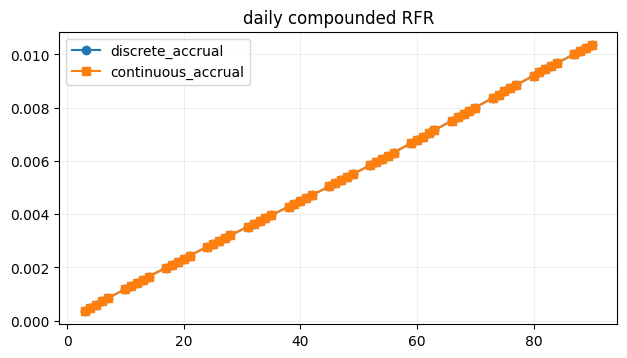

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("daily compounded RFR")
ax.plot(data["day"], data["discrete_accrual"], marker="o", label="discrete_accrual")
ax.plot(data["day"], data["continuous_accrual"], marker="s", label="continuous_accrual")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## futures-forward convexity

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

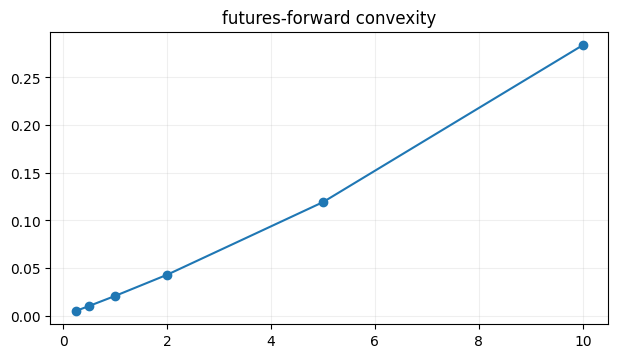

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("futures-forward convexity")
ax.plot(data["maturity"], data["futures_forward_bp"], marker="o")
ax.grid(alpha=.2)
plt.show()

## Bachelier/shifted SABR smile

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

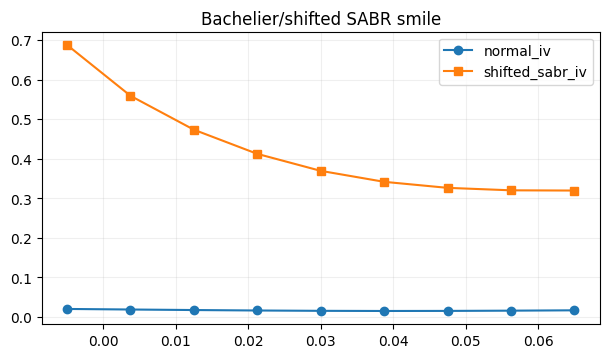

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("Bachelier/shifted SABR smile")
ax.plot(data["strike"], data["normal_iv"], marker="o", label="normal_iv")
ax.plot(data["strike"], data["shifted_sabr_iv"], marker="s", label="shifted_sabr_iv")
ax.legend()
ax.grid(alpha=.2)
plt.show()

## sticky-strike vs Bartlett delta

単一のaggregate scoreではなく、構造別・時間別・stress別に読む。

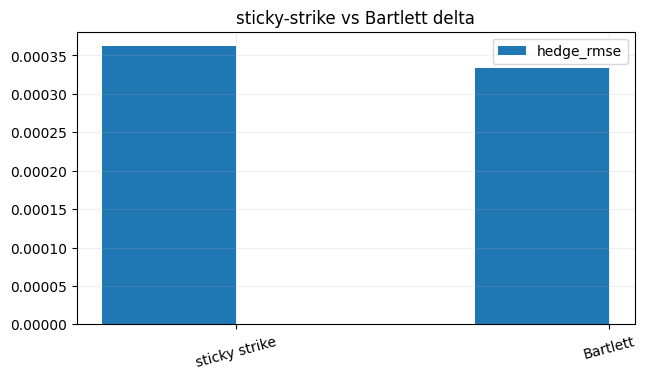

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.set_title("sticky-strike vs Bartlett delta")
x = np.arange(len(data["hedge_names"]))
ax.bar(x - .18, data["hedge_rmse"], width=.36, label="hedge_rmse")
ax.set_xticks(x, data["hedge_names"], rotation=15)
ax.legend()
ax.grid(alpha=.2)
plt.show()

## Gate判定

artifact fingerprint、finite values、主要identityを機械的に確認する。

In [8]:
assert all(np.all(np.isfinite(values)) for values in artifact_data.values() if values.dtype.kind in 'fiu')
assert manifest['companions'][artifact.name] == hashlib.sha256(artifact.read_bytes()).hexdigest()
assert set(manifest['companion_schemas'][artifact.name]) == set(artifact_data)
print('PASS: fingerprint, schema, units, and finite-value checks')

PASS: fingerprint, schema, units, and finite-value checks


## 限界とnegative results

本巻の数値はsynthetic fixtureによる教育・integration検証であり、市場予測力、収益性、実運用較正を示さない。複雑モデルがbaselineに勝たない場合もnegative resultとして保持する。

## Research track

未査読preprintや重いモデルはoptional profileに隔離し、core artifact・notebook・book・portalの再構築を妨げない。

## 参考文献

ARRC RFR conventions; Hagan et al. (2002), Managing Smile Risk; Bartlett (2006).

## まとめ

価格・統計誤差だけでなく、hard constraints、下流risk、計算量、data/model limitationsを同じ成果物に固定した。